## Часть 1. SLIM: постановка задачи и методы оптимизации

В первой части проекта рассматривается модель SLIM (Sparse Linear Methods).
Задача заключается в поиске матрицы весов $W \in \mathbb{R}^{D \times D}$, которая позволяет аппроксимировать пользователь-товарную матрицу $A \in \mathbb{R}^{N \times D}$:

$$
A \approx A W
$$

Оптимизационная задача имеет вид:

$$
f(W) = \frac{1}{2} |A - A W|_{F} + \lambda |W|_{1} + \frac{\beta}{2} |W|_{F}
$$

где:

- $|A - AW|_F$ — ошибка реконструкции  
- $|W|_1$ — L1-регуляризация
- $|W|_F$ — L2-регуляризация

Дополнительно накладываются ограничения:

$
W \ge 0, \quad w_{ii} = 0
$

---

### Методы оптимизации

Для решения задачи используются следующие методы.


#### 1. Координатный спуск

Рассматриваются три стратегии:

- Cyclic — последовательный перебор координат  
- Random — случайный порядок  
- Greedy (Gauss–Southwell) — выбор координаты с максимальным модулем градиента  

#### 2. Проксимальный градиентный спуск

Обновление имеет вид:

Шаг выбирается как:

$$
\eta = \frac{1}{\lambda_{\max}(A^T A) + \beta}
$$


#### 3. Mini-batch Стохастический градиентный спуск

- Mini-batch SGD — обновление по подвыборке пользователей  



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
import math
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'cyclic': 'steelblue',
    'random': 'orange',
    'greedy': 'purple',
    'gd':     'tomato',
    'sgd':    'gray',
}

In [ ]:
def generate_user_item_matrix(N=200, D=50, density=0.2, seed=42):
    rng = np.random.RandomState(seed)
    K = 5

    user_topics = rng.randint(0, K, size=N)
    item_topics = rng.randint(0, K, size=D)

    A = np.zeros((N, D))
    for u in range(N):
        for i in range(D):
            p = 0.5 if user_topics[u] == item_topics[i] else 0.05
            if rng.rand() < p:
                A[u, i] = 1.0

    print(f"User-item matrix: {N} users × {D} items")
    return A

N, D = 200,50
A = generate_user_item_matrix(N=N, D=D)


def soft_threshold(z, lam):
    """S_λ(z) = sign(z) * max(|z| - λ, 0)"""
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


def slim_objective(A, W, lam, beta):
    """f(W) = 1/2 ||A - AW||_F^2 + λ||W||_1 + (β/2)||W||_F^2"""
    residual = A - A @ W
    loss = 0.5 * np.sum(residual ** 2)
    l1   = lam  * np.sum(np.abs(W))
    l2   = (beta / 2.0) * np.sum(W ** 2)

    return loss + l1 + l2


def sparsity(W):
    return np.mean(np.abs(W) < 1e-8)


def reconstruction_error(A, W):
    return np.linalg.norm(A - A @ W, 'fro') / (np.linalg.norm(A, 'fro') + 1e-10)


def precompute(A):
    ATA = A.T @ A
    col_norms_sq = np.diag(ATA)
    return ATA, col_norms_sq

ATA, col_norms_sq = precompute(A)

def update_coordinate_slim(W, ATA, col_norms_sq, i, j, lam, beta):
    if i == j:
        return 0.0
    c_ij = ATA[i, j] - ATA[j, :] @ W[:, i] + ATA[j, j] * W[j, i]
    d_jj = col_norms_sq[j] + beta
    return max(0.0, soft_threshold(c_ij, lam) / d_jj)

def compute_all_gradients(W, ATA, i, beta):
    return ATA @ W[:, i] - ATA[i, :] + beta * W[:, i]

User-item matrix: 200 users × 50 items


In [ ]:
def coordinate_descent_slim(A, lam=0.1, beta=0.01, strategy='cyclic',
                             n_epochs=30, seed=0):
    rng = np.random.RandomState(seed)
    N, D = A.shape
    ATA, col_norms_sq = precompute(A)
    W = np.zeros((D, D))

    history = {'loss': [], 'sparsity': [], 'recon_err': [], 'time': []}

    def record():
        history['loss'].append(slim_objective(A, W, lam, beta))
        history['sparsity'].append(sparsity(W))
        history['recon_err'].append(reconstruction_error(A, W))

    record()
    history['time'].append(0.0)
    t_start = time.time()

    for epoch in range(n_epochs):

        if strategy == 'cyclic':
            col_order = np.arange(D)
        elif strategy == 'random':
            col_order = rng.permutation(D)
        elif strategy == 'greedy':
            grad_norms = np.array([
                np.linalg.norm(compute_all_gradients(W, ATA, i, beta))
                for i in range(D)
            ])
            col_order = np.argsort(-grad_norms)
        else:
            raise ValueError(f"Неизвестная стратегия: {strategy}")

        for i in col_order:
            if strategy == 'greedy':
                grads = np.abs(compute_all_gradients(W, ATA, i, beta))
                grads[i] = 0
                row_order = np.argsort(-grads)
            elif strategy == 'random':
                row_order = rng.permutation(D)
            else:
                row_order = np.arange(D)

            for j in row_order:
                if i == j:
                    continue
                W[j, i] = update_coordinate_slim(W, ATA, col_norms_sq, i, j, lam, beta)

        record()
        history['time'].append(time.time() - t_start)

    return W, history

In [ ]:
def gradient_descent_slim(A, lam=0.1, beta=0.01, eta=1e-4, n_epochs=30):
    N, D = A.shape
    ATA, _ = precompute(A)
    W = np.zeros((D, D))
    L = np.linalg.norm(ATA, 2) + beta
    eta = 1.0 / L
    history = {'loss': [], 'sparsity': [], 'recon_err': [], 'time': []}

    def record():
        history['loss'].append(slim_objective(A, W, lam, beta))
        history['sparsity'].append(sparsity(W))
        history['recon_err'].append(reconstruction_error(A, W))

    record()
    history['time'].append(0.0)
    t_start = time.time()

    for _ in range(n_epochs):
        Grad  = ATA @ W - ATA + beta * W
        W_new = soft_threshold(W - eta * Grad, eta * lam)
        W_new = np.maximum(W_new, 0.0)
        np.fill_diagonal(W_new, 0.0)
        W = W_new

        record()
        history['time'].append(time.time() - t_start)

    return W, history

In [ ]:
def sgd_slim(A, lam=0.1, beta=0.01, eta=1e-5, n_epochs=30, seed=1):
    rng = np.random.RandomState(seed)
    N, D = A.shape
    ATA, col_norms_sq = precompute(A)
    W = np.zeros((D, D))

    history = {'loss': [], 'sparsity': [], 'recon_err': [], 'time': []}

    def record():
        history['loss'].append(slim_objective(A, W, lam, beta))
        history['sparsity'].append(sparsity(W))
        history['recon_err'].append(reconstruction_error(A, W))

    record()
    history['time'].append(0.0)
    t_start = time.time()
    steps_per_epoch = D * D

    for epoch in range(n_epochs):
        eta = 1e-4 / (1 + epoch)
        for _ in range(steps_per_epoch):
            i = rng.randint(0, D)
            j = rng.randint(0, D)
            if i == j:
                continue
            grad_ij = ATA[j, :] @ W[:, i] - ATA[i, j] + beta * W[j, i]
            W[j, i] = max(0.0, soft_threshold(W[j, i] - eta * grad_ij, eta * lam))

        record()
        history['time'].append(time.time() - t_start)

    return W, history

In [ ]:
def sgd_slim_batch(A, lam=0.1, beta=0.01, eta=1e-2,
                   batch_size=32, n_epochs=30, seed=1):
    rng = np.random.RandomState(seed)
    N, D = A.shape

    W = np.zeros((D, D))

    history = {'loss': [], 'sparsity': [], 'recon_err': [], 'time': []}
    def record():
        history['loss'].append(slim_objective(A, W, lam, beta))
        history['sparsity'].append(sparsity(W))
        history['recon_err'].append(reconstruction_error(A, W))

    record()
    history['time'].append(0.0)
    t_start = time.time()

    for epoch in range(n_epochs):
        perm = rng.permutation(N)
        for start in range(0, N, batch_size):
            batch_idx = perm[start:start + batch_size]
            A_batch = A[batch_idx]

            grad = A_batch.T @ (A_batch @ W - A_batch)
            grad += beta * W

            W = soft_threshold(W - eta * grad, eta * lam)
            W = np.maximum(W, 0.0)
            np.fill_diagonal(W, 0.0)
        record()

        history['time'].append(time.time() - t_start)

    return W, history

In [ ]:
LAM  = 0.05
BETA = 0.01
N_EPOCHS = 60

eta_gd = 1.0 / (np.linalg.eigvalsh(ATA).max() + BETA)

W_cyc,  hist_cyc  = coordinate_descent_slim(A, lam=LAM, beta=BETA, strategy='cyclic',  n_epochs=N_EPOCHS)
W_rnd,  hist_rnd  = coordinate_descent_slim(A, lam=LAM, beta=BETA, strategy='random',  n_epochs=N_EPOCHS)
W_grd,  hist_grd  = coordinate_descent_slim(A, lam=LAM, beta=BETA, strategy='greedy',  n_epochs=N_EPOCHS)
W_gd,   hist_gd   = gradient_descent_slim  (A, lam=LAM, beta=BETA, eta=eta_gd,          n_epochs=N_EPOCHS)
W_sgd_batch, hist_sgd_batch = sgd_slim_batch(
    A,
    lam=LAM,
    beta=BETA,
    eta=eta_gd*5,
    batch_size=32,
    n_epochs=N_EPOCHS
)



ФИНАЛЬНЫЕ ЗНАЧЕНИЯ
CD-Cyclic    f = 4.380544e+02
CD-Random    f = 4.380544e+02
CD-Greedy    f = 4.380544e+02
Prox-GD      f = 4.380839e+02
SGD (batch)  f = 4.499509e+02


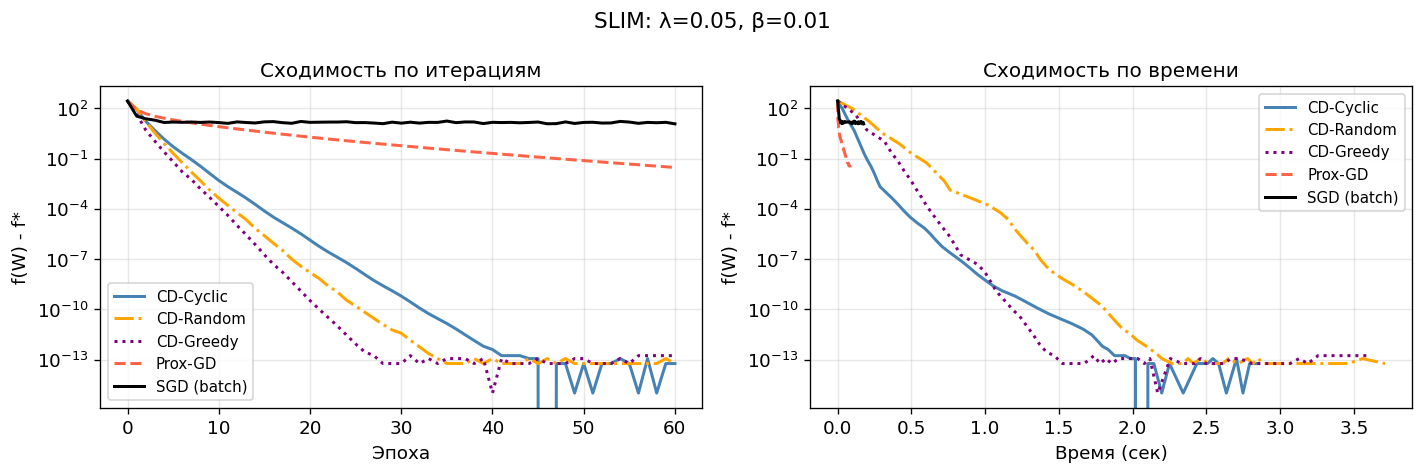

In [ ]:
W_ref, hist_ref = gradient_descent_slim(
    A, lam=LAM, beta=BETA, n_epochs=500
)
f_star = hist_ref['loss'][-1]

print("\nФИНАЛЬНЫЕ ЗНАЧЕНИЯ")
for name, hist in [
    ('CD-Cyclic', hist_cyc),
    ('CD-Random', hist_rnd),
    ('CD-Greedy', hist_grd),
    ('Prox-GD', hist_gd),
    ('SGD (batch)', hist_sgd_batch)
]:
    print(f"{name:<12} f = {hist['loss'][-1]:.6e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods_slim = [
    ('CD-Cyclic', hist_cyc, COLORS['cyclic'], '-'),
    ('CD-Random', hist_rnd, COLORS['random'], '-.'),
    ('CD-Greedy', hist_grd, COLORS['greedy'], ':'),
    ('Prox-GD',   hist_gd,  COLORS['gd'],     '--'),
    ('SGD (batch)', hist_sgd_batch, 'black', '-')
]

ax = axes[0]
for name, hist, color, ls in methods_slim:
    ax.semilogy(np.array(hist['loss']) - f_star + 1e-15,
                label=name, color=color, ls=ls)
ax.set_xlabel('Эпоха')
ax.set_ylabel('f(W) - f*')
ax.set_title('Сходимость по итерациям')
ax.legend()


ax = axes[1]
for name, hist, color, ls in methods_slim:
    ax.semilogy(hist['time'],
                np.array(hist['loss']) - f_star + 1e-15,
                label=name, color=color, ls=ls)
ax.set_xlabel('Время (сек)')
ax.set_ylabel('f(W) - f*')
ax.set_title('Сходимость по времени')
ax.legend()


plt.suptitle(f'SLIM: λ={LAM}, β={BETA}', fontsize=13)
plt.tight_layout()
plt.show()


f_star (GD) = 4.380544e+02
SGD final gap = 1.923600e+00


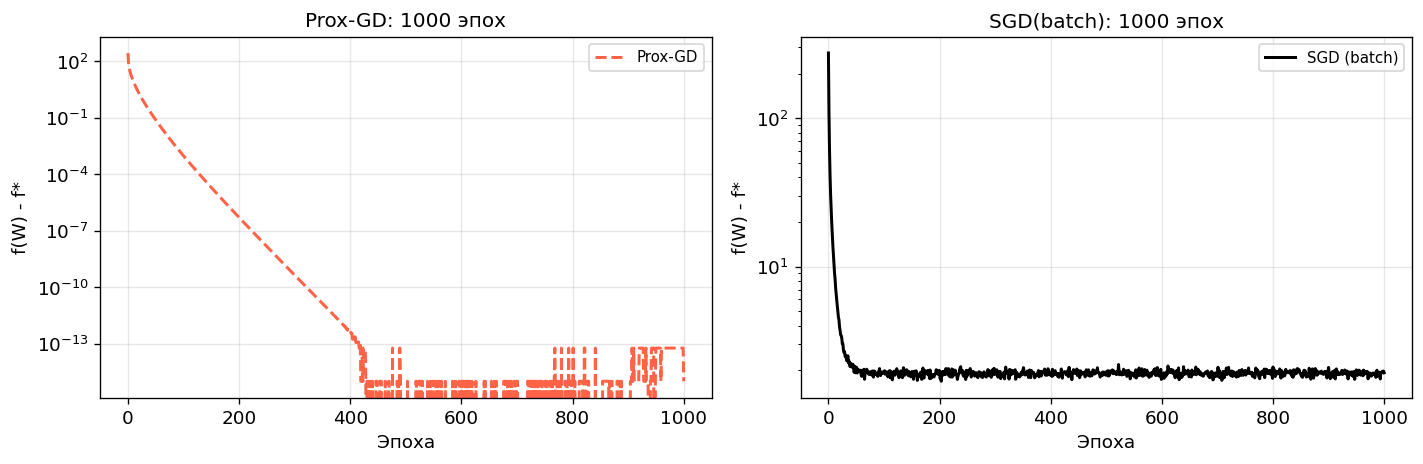

In [ ]:
N_EPOCHS_LONG = 1000

W_gd_long, hist_gd_long = gradient_descent_slim(
    A,
    lam=LAM,
    beta=BETA,
    n_epochs=N_EPOCHS_LONG
)

f_star = hist_gd_long['loss'][-1]

W_sgd_batch_long, hist_sgd_batch_long = sgd_slim_batch(
    A,
    lam=LAM,
    beta=BETA,
    eta=eta_gd,
    batch_size=32,
    n_epochs=N_EPOCHS_LONG
)

print(f"f_star (GD) = {f_star:.6e}")
print(f"SGD final gap = {hist_sgd_batch_long['loss'][-1] - f_star:.6e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(
    np.array(hist_gd_long['loss']) - f_star + 1e-15,
    label='Prox-GD',
    color=COLORS['gd'],
    ls='--'
)
ax.set_xlabel('Эпоха')
ax.set_ylabel('f(W) - f*')
ax.set_title('Prox-GD: 1000 эпох')
ax.legend()

ax = axes[1]
ax.semilogy(
    np.array(hist_sgd_batch_long['loss']) - f_star + 1e-15,
    label='SGD (batch)',
    color='black',
    ls='-'
)
ax.set_xlabel('Эпоха')
ax.set_ylabel('f(W) - f*')
ax.set_title('SGD(batch): 1000 эпох')
ax.legend()

plt.tight_layout()
plt.show()

По графикам сходимости по итерациям и по времени можно сделать следующие выводы:

- **Coordinate Descent (Greedy / Random / Cyclic)** показывают наилучшую сходимость по значению функции.

- **Greedy CD** демонстрирует наиболее быструю сходимость среди всех методов, но выполняется дольше по времени, так как на каждой итерации требует дополнительного вычисления и сравнения градиентов для выбора координаты с максимальным вкладом.

- **Random CD** показывает сопоставимые результаты с greedy и стабильно улучшает значение функции.

- **Cyclic CD** сходится медленнее остальных вариантов координатного спуска, но всё равно значительно лучше GD и SGD.

- **Proximal Gradient Descent (Prox-GD)** сходится существенно хуже координатных методов.

- **SGD (batch)** показывает наихудшую сходимость: значение функции практически не улучшается после начальных итераций.

# Часть 2, Topic Modelling
В данной части рассматривается задача факторизации матрицы наблюдений \(N\) в произведение двух неотрицательных матриц $(\Phi$) и $(\Theta$)
Оптимизируется логарифм правдоподобия:

$$
\mathcal{L} = \sum_{d,w} N_{dw} \log P_{dw}
$$


## Используемые методы

### 1. Alternating Gradient Descent (покоординатный спуск)

Метод основан на попеременной оптимизации матриц $(\Phi$) и $(\Theta$):

- выполняется градиентный шаг по одной матрице при фиксированной другой  
- затем применяется проекция на неотрицательное множество:

$$
\Phi \ge 0, \quad \Theta \ge 0
$$

- дополнительно выполняется нормировка столбцов для интерпретации как распределений

### 2. EM-алгоритм

Метод основан на максимизации правдоподобия через скрытые переменные.

**E-step:**

$$
p(t \mid d, w) = \frac{\varphi_{wt}\theta_{td}}{\sum_s \varphi_{ws}\theta_{sd}}
$$

**M-step:**

$$
\Phi, \Theta \leftarrow \text{normalize}(\text{expected counts})
$$

In [ ]:
np.random.seed(42)

D = 50
W = 80
T = 5

N_ITER = 200
ETA = 0.01
EPS = 1e-12
np.random.seed(42)
D, W, T = 50, 80, 5

Phi_true   = np.random.dirichlet(0.1 * np.ones(W), size=T).T
Theta_true = np.random.dirichlet(0.5 * np.ones(T), size=D).T

lam = (Phi_true @ Theta_true).T * 10
N = np.random.poisson(lam).astype(float)

print(f"Средняя заполненность: {(N > 0).mean():.2f}")
print(f"Среднее значение: {N.mean():.2f}")

Средняя заполненность: 0.10
Среднее значение: 0.12


In [ ]:
def compute_P(Phi, Theta):
    return (Phi @ Theta).T

def log_likelihood(N, Phi, Theta):
    P = compute_P(Phi, Theta)
    return np.sum(N * np.log(P + EPS))


def gradients(N, Phi, Theta):
    P = compute_P(Phi, Theta)
    R = N / (P + EPS)

    grad_Theta = Phi.T @ R.T
    grad_Phi   = R.T   @ Theta.T

    return grad_Phi, grad_Theta

In [ ]:
def project_Phi(Phi):
    Phi = np.maximum(Phi, 0)
    Phi /= np.maximum(Phi.sum(axis=0, keepdims=True), EPS)
    return Phi


def project_Theta(Theta):
    Theta = np.maximum(Theta, 0)
    Theta /= np.maximum(Theta.sum(axis=0, keepdims=True), EPS)
    return Theta

def init_matrices():
    Phi = project_Phi(np.random.rand(W, T))
    Theta = project_Theta(np.random.rand(T, D))
    return Phi, Theta

In [ ]:
def e_step(N, Phi, Theta):
    D, W = N.shape
    T = Phi.shape[1]

    P_dw = (Phi @ Theta).T
    P_dw = np.maximum(P_dw, 1e-12)

    P_tdw = np.zeros((D, W, T))

    for t in range(T):
        P_tdw[:, :, t] = (Theta[t, :][:, None]) * Phi[:, t][None, :]

    P_tdw /= P_dw[:, :, None]

    return P_tdw

def m_step(N, P_tdw):
    D, W = N.shape
    T = P_tdw.shape[2]

    n_dwt = N[:, :, None] * P_tdw

    n_wt = np.sum(n_dwt, axis=0)

    n_td = np.sum(n_dwt, axis=1).T

    Phi = np.maximum(n_wt, 0)
    Phi /= np.maximum(Phi.sum(axis=0, keepdims=True), 1e-12)

    Theta = np.maximum(n_td, 0)
    Theta /= np.maximum(Theta.sum(axis=0, keepdims=True), 1e-12)

    return Phi, Theta

In [ ]:
def em_topic_model(N, n_iter=50):
    D, W = N.shape
    T = 5

    Phi = np.random.rand(W, T)
    Phi /= Phi.sum(axis=0, keepdims=True)

    Theta = np.random.rand(T, D)
    Theta /= Theta.sum(axis=0, keepdims=True)

    history_L = []
    history_t = []

    t0 = time.time()

    for _ in range(n_iter):

        P_tdw = e_step(N, Phi, Theta)
        Phi, Theta = m_step(N, P_tdw)
        P = (Phi @ Theta).T
        P = np.maximum(P, 1e-12)
        L = np.sum(N * np.log(P))

        history_L.append(L)
        history_t.append(time.time() - t0)

    return Phi, Theta, history_L, history_t

In [ ]:
def alternating_gd(N, n_iter=50, eta=1e-3):
    D, W = N.shape
    T = 5

    Phi = np.random.rand(W, T)
    Phi /= Phi.sum(axis=0, keepdims=True)

    Theta = np.random.rand(T, D)
    Theta /= Theta.sum(axis=0, keepdims=True)

    history_L = []
    history_t = []

    t0 = time.time()

    eta_init = 1.0

    for it in range(n_iter):

        eta = eta_init / math.sqrt((1 + it))
        grad_Phi, grad_Theta = gradients(N, Phi, Theta)
        Theta = project_Theta(Theta + eta * grad_Theta)

        grad_Phi, grad_Theta = gradients(N, Phi, Theta)
        Phi = project_Phi(Phi + eta * grad_Phi)

        L = log_likelihood(N, Phi, Theta)
        history_L.append(L)
        history_t.append(time.time() - t0)

    return Phi, Theta, history_L, history_t

In [ ]:
Phi_em, Theta_em, L_em, T_em = em_topic_model(N, n_iter=2000)
Phi_gd, Theta_gd, L_gd, T_gd = alternating_gd(N, n_iter=2000)

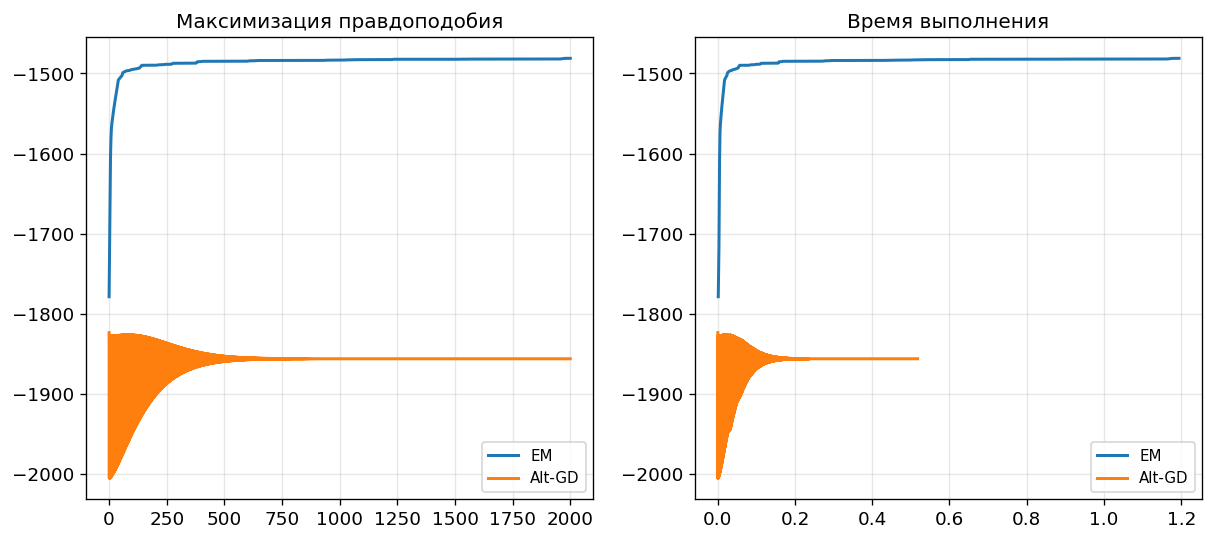

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(L_em, label='EM')
plt.plot(L_gd, label='Alt-GD')
plt.title('Максимизация правдоподобия')
plt.legend()

plt.subplot(1,2,2)
plt.plot(T_em, L_em, label='EM')
plt.plot(T_gd, L_gd, label='Alt-GD')
plt.title('Время выполнения')
plt.legend()

plt.show()

По графикам логарифма правдоподобия по итерациям и по времени можно сделать следующие выводы:

- **EM-алгоритм** достигает более высокого значения log-likelihood по сравнению с Alternating Gradient Descent.

- Уже на ранних итерациях EM демонстрирует резкий рост целевой функции и быстро выходит на плато.

- **Alternating Gradient Descent** сходится медленнее и стабилизируется на существенно более низком значении log-likelihood.

- По времени EM также показывает более эффективную сходимость: за меньшее время достигается лучшее качество решения.

- Разрыв между методами сохраняется на протяжении всего эксперимента, что подтверждает преимущество EM как по скорости, так и по итоговому качеству.

# Часть 3 — Lasso: сравнение методов оптимизации

В данной части рассматривается задача L1-регуляризованной линейной регрессии (Lasso).

Оптимизационная задача имеет вид:

$$
f(w) = \frac{1}{2} \|Xw - y\|_2^2 + \lambda \|w\|_1
$$

где:

- $X \in \mathbb{R}^{n \times d}$ — матрица признаков  
- $y \in \mathbb{R}^n$ — вектор откликов  
- $w \in \mathbb{R}^d$ — вектор параметров  
- $\lambda > 0$ — коэффициент регуляризации  



## Используемые методы

### 1. Coordinate Descent

Рассматриваются три стратегии выбора координат:

- **Cyclic** — последовательный проход по всем координатам  
- **Random** — случайный порядок координат на каждой эпохе  
- **Greedy (Gauss–Southwell)** — выбор координаты с максимальным модулем частной производной  

Обновление каждой координаты выполняется аналитически:

$$
w_j \leftarrow \frac{S_\lambda(\rho_j)}{\|x_j\|^2}
$$

где:

$$
\rho_j = x_j^T r, \quad r = y - Xw
$$

и $S_\lambda$ — оператор soft-thresholding.


### 2. Proximal Gradient Descent

Метод основан на разбиении функции на гладкую и негладкую части.

Итерация имеет вид:

$$
w^{k+1} = S_{\eta \lambda}\left(w^k - \eta \nabla f(w^k)\right)
$$

где:

$$
\nabla f(w) = X^T (Xw - y)
$$

Шаг выбирается как:

$$
\eta = \frac{1}{L}, \quad L = \lambda_{\max}(X^T X)
$$


### 3. Mini-batch SGD

Стохастический метод с использованием мини-батчей.

Градиент оценивается по подвыборке данных:

$$
g_k = \frac{1}{b} X_b^T (X_b w - y_b)
$$

Обновление параметров:

$$
w^{k+1} = S_{\eta_k \lambda}(w^k - \eta_k g_k)
$$

Шаг убывает по правилу:

$$
\eta_k = \frac{\eta_0}{\sqrt{k+1}}
$$


In [ ]:
np.random.seed(42)

n_samples = 500
n_features = 100
true_sparsity = 10

X = np.random.randn(n_samples, n_features)
w_true = np.zeros(n_features)

nonzero_idx = np.random.choice(n_features, true_sparsity, replace=False)
w_true[nonzero_idx] = np.random.randn(true_sparsity)

noise = 0.1 * np.random.randn(n_samples)
y = X @ w_true + noise

X = X / (np.linalg.norm(X, axis=0, keepdims=True) + 1e-12)



In [ ]:
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)

def lasso_objective(X, y, w, lam):
    residual = X @ w - y
    return 0.5 * np.sum(residual ** 2) + lam * np.sum(np.abs(w))

def sparsity_vec(w):
    return np.mean(np.abs(w) < 1e-8)

def make_history():
    return {'loss': [], 'sparsity': [], 'time': []}

def record(h, X, y, w, lam, t):
    h['loss'].append(lasso_objective(X, y, w, lam))
    h['sparsity'].append(sparsity_vec(w))
    h['time'].append(t)

In [ ]:
def _cd_epoch_cyclic(X, w, residual, col_norms_sq, lam):
    d = X.shape[1]
    for j in range(d):
        residual += X[:, j] * w[j]
        rho = X[:, j] @ residual
        w[j] = soft_threshold(rho, lam) / col_norms_sq[j]
        residual -= X[:, j] * w[j]

def _cd_epoch_random(X, w, residual, col_norms_sq, lam, rng):
    d = X.shape[1]
    for j in rng.permutation(d):
        residual += X[:, j] * w[j]
        rho = X[:, j] @ residual
        w[j] = soft_threshold(rho, lam) / col_norms_sq[j]
        residual -= X[:, j] * w[j]

def _cd_epoch_gs(X, w, residual, col_norms_sq, lam):
    d = X.shape[1]
    for _ in range(d):
        rho = X.T @ residual
        score = np.where(
            np.abs(w) > 1e-10,
            np.abs(rho - lam * np.sign(w)),
            np.maximum(np.abs(rho) - lam, 0.0)
        )
        j = np.argmax(score)
        residual += X[:, j] * w[j]
        rho_j = X[:, j] @ residual
        w[j] = soft_threshold(rho_j, lam) / col_norms_sq[j]
        residual -= X[:, j] * w[j]

def coordinate_descent_lasso(X, y, lam=0.1, n_epochs=50, strategy='cyclic', seed=0):
    n, d = X.shape
    w = np.zeros(d)
    col_norms_sq = np.sum(X ** 2, axis=0)
    residual = y - X @ w
    rng = np.random.RandomState(seed)

    h = make_history()
    record(h, X, y, w, lam, 0.0)
    t0 = time.time()

    for _ in range(n_epochs):
        if strategy == 'cyclic':
            _cd_epoch_cyclic(X, w, residual, col_norms_sq, lam)
        elif strategy == 'random':
            _cd_epoch_random(X, w, residual, col_norms_sq, lam, rng)
        elif strategy == 'greedy':
            _cd_epoch_gs(X, w, residual, col_norms_sq, lam)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        record(h, X, y, w, lam, time.time() - t0)

    return w, h

In [ ]:
def proximal_gd_lasso(X, y, lam=0.1, n_epochs=50, adaptive=False):
    n, d = X.shape
    w = np.zeros(d)

    L = np.linalg.norm(X.T @ X, 2)
    eta = 1.0 / L

    h = make_history()
    record(h, X, y, w, lam, 0.0)
    t0 = time.time()

    for _ in range(n_epochs):
        grad = X.T @ (X @ w - y)

        if not adaptive:
            w = soft_threshold(w - eta * grad, eta * lam)
        else:
            f0 = 0.5 * np.sum((X @ w - y) ** 2)
            step = eta * 2.0
            for _ in range(50):
                w_new = soft_threshold(w - step * grad, step * lam)
                f_new = 0.5 * np.sum((X @ w_new - y) ** 2)
                rhs = f0 + grad @ (w_new - w) + (1.0 / (2 * step)) * np.sum((w_new - w) ** 2)
                if f_new <= rhs + 1e-10:
                    break
                step *= 0.5
            w = w_new
            eta = step

        record(h, X, y, w, lam, time.time() - t0)

    return w, h

def sgd_lasso(X, y, lam=0.1, batch_size=32, n_epochs=50, seed=42):
    rng = np.random.RandomState(seed)
    n, d = X.shape
    w = np.zeros(d)

    max_row_norm_sq = np.max(np.sum(X ** 2, axis=1))
    L_b = max_row_norm_sq / batch_size
    eta0 = 1.0 / L_b

    lam_n = lam / n

    h = make_history()
    record(h, X, y, w, lam, 0.0)
    t0 = time.time()

    for epoch in range(n_epochs):
        indices = rng.permutation(n)
        eta_k = eta0 / np.sqrt(epoch + 1)

        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            b = len(batch_idx)

            X_b = X[batch_idx]
            y_b = y[batch_idx]

            grad = X_b.T @ (X_b @ w - y_b) / b

            w = soft_threshold(w - eta_k * grad, eta_k * lam_n)

        record(h, X, y, w, lam, time.time() - t0)

    return w, h

In [ ]:
LAM = 0.1
N_EPOCHS = 60

w_cyc, h_cyc = coordinate_descent_lasso(
    X, y, lam=LAM, n_epochs=N_EPOCHS, strategy='cyclic'
)
w_rnd, h_rnd = coordinate_descent_lasso(
    X, y, lam=LAM, n_epochs=N_EPOCHS, strategy='random'
)
w_gs, h_gs = coordinate_descent_lasso(
    X, y, lam=LAM, n_epochs=N_EPOCHS, strategy='greedy'
)
w_pgd, h_pgd = proximal_gd_lasso(
    X, y, lam=LAM, n_epochs=N_EPOCHS, adaptive=False
)
w_sgd, h_sgd = sgd_lasso(
    X, y, lam=LAM, batch_size=32, n_epochs=N_EPOCHS
)

methods = [
    ("CD Cyclic", h_cyc, 'C0', '-'),
    ("CD Random", h_rnd, 'C1', '--'),
    ("CD Greedy", h_gs, 'C2', '-.'),
    ("Prox-GD", h_pgd, 'C3', '-'),
    ("SGD", h_sgd, 'C5', ':'),
]

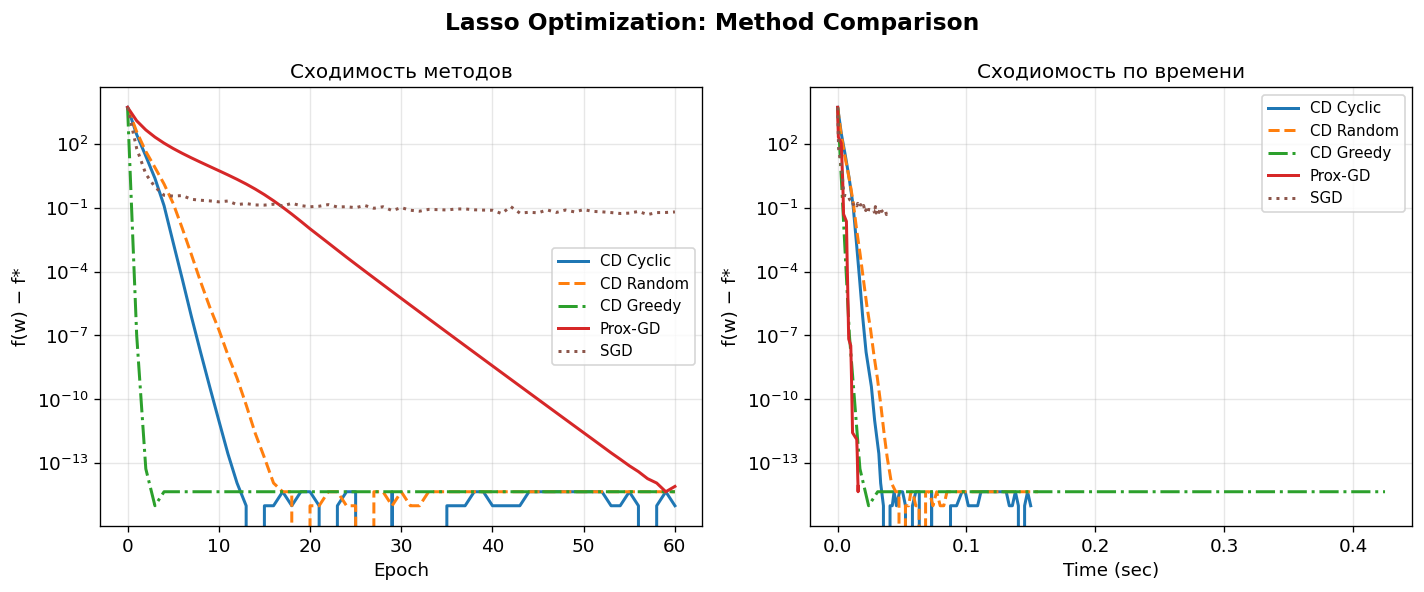

In [ ]:

f_star = min(h['loss'][-1] for _, h, *_ in methods)
eps = 1e-15

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Lasso Optimization: Method Comparison", fontsize=14, fontweight='bold')

ax = axes[0]
for name, h, color, ls in methods:
    ax.semilogy(np.array(h['loss']) - f_star + eps,
                label=name, color=color, linestyle=ls, linewidth=1.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("f(w) − f*")
ax.set_title("Сходимость методов")
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for name, h, color, ls in methods:
    ax.semilogy(h['time'], np.array(h['loss']) - f_star + eps,
                label=name, color=color, linestyle=ls, linewidth=1.8)
ax.set_xlabel("Time (sec)")
ax.set_ylabel("f(w) − f*")
ax.set_title("Сходиомость по времени")
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

- Метод **Coordinate Descent (Greedy)** демонстрирует наилучшую сходимость по числу итераций, достигая минимума быстрее всех.

- Методы **Coordinate Descent (Cyclic)** и **Coordinate Descent (Random)** также сходятся к оптимуму, но требуют большего числа эпох по сравнению с greedy-стратегией.

- Метод **Proximal Gradient Descent** сходится значительно медленнее по числу итераций, однако показывает стабильное монотонное уменьшение функции.

- Метод **SGD** практически не сходится за рассматриваемое число эпох и застревает на значительно большем значении функции.

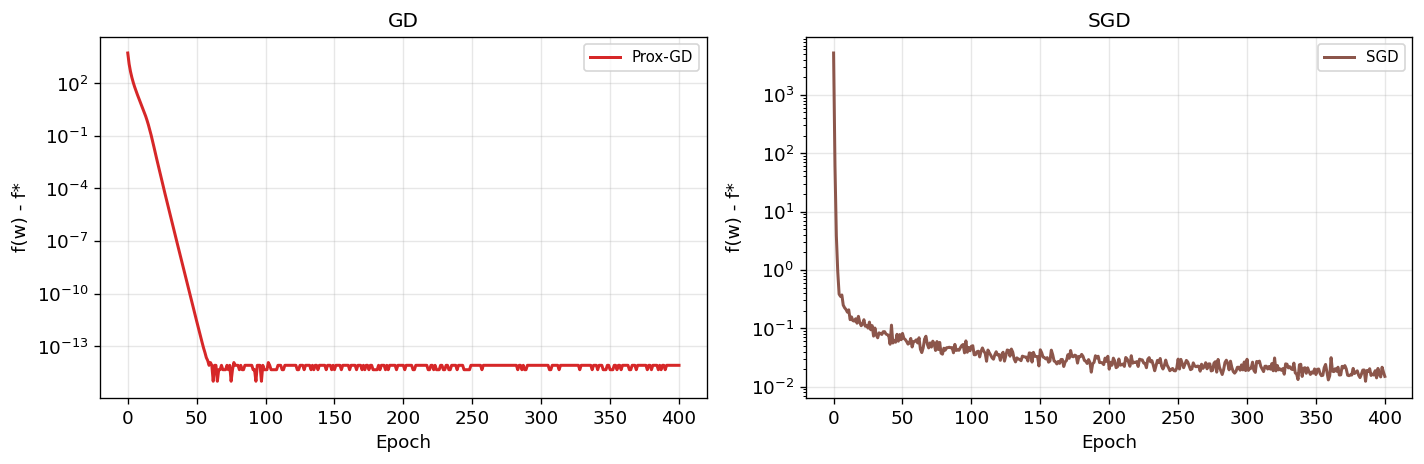

In [ ]:
N_EPOCHS_LONG = 400

w_gd_long, h_gd_long = proximal_gd_lasso(
    X, y, lam=LAM, n_epochs=N_EPOCHS_LONG, adaptive=False
)

w_sgd_long, h_sgd_long = sgd_lasso(
    X, y, lam=LAM, batch_size=32, n_epochs=N_EPOCHS_LONG
)

f_star_long = min(
    min(h['loss']) for h in [h_sgd, h_gd_long, h_sgd_long]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(
    np.array(h_gd_long['loss']) - f_star_long + 1e-15,
    label='Prox-GD',
    color='C3'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('f(w) - f*')
ax.set_title('GD')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(
    np.array(h_sgd_long['loss']) - f_star_long + 1e-15,
    label='SGD',
    color='C5'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('f(w) - f*')
ax.set_title('SGD')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()